# Retrieval Augmented Generation
## Step 3: Vectorstores and Embeddings

Recall the overall workflow for retrieval augmented generation (RAG):
<img src="img/RAG.JPG" width="2000"/>

In [2]:
import os
# get home and job id
home_dir =  os.getenv('HOME')
job_id = os.getenv('SLURM_JOB_ID')

# get ollama directory or default to home
ollama_dir = os.getenv('OLLAMA_BASE_DIR', home_dir)

try:    
    with open(f"{ollama_dir}/ollama/host_{job_id}.txt") as f:
        HOST = f.read().strip()
    with open(f"{ollama_dir}/ollama/port_{job_id}.txt") as f:
        PORT = f.read().strip()
    ollama_url = f"http://{HOST}:{PORT}"
except Exception as e:
    print("[⚠️] Could not read host/port, you manually set the `ollama_url` below.")

print("The port that serve ollama is: ", ollama_url)


The port that serve ollama is:  http://bcm-dgxa100-0003:50540


## Reload Step 1+2: Documents Loader and Splitting

In [3]:
from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader   
loader = DirectoryLoader(
    "mdocs",
    glob="*.pdf",          # match PDFs (use ** for recursion)
    loader_cls=PyPDFLoader,   # use PyPDF for each matched file
    show_progress=True,
    use_multithreading=True,
    max_concurrency=8,
)

docs = loader.load()
print(len(docs), docs[0].metadata)

/users/tuev/llm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 3/3 [00:01<00:00,  1.68it/s]

52 {'producer': 'PDFlib+PDI 9.3.1p2 (C++/Win64)', 'creator': 'PTC Arbortext Layout Developer 12.1.6180/W-x64', 'creationdate': '2022-08-22T17:11:11+05:30', 'title': 'Correction: Psychological impacts from COVID-19 among university students: Risk factors across seven states in the United States', 'epsprocessor': 'PStill version 1.84.42', 'author': 'Matthew H. E. M. Browning, Lincoln R. Larson, Iryna Sharaievska, Alessandro Rigolon, Olivia McAnirlin, Lauren Mullenbach, Scott Cloutier, Tue M. Vu, Jennifer Thomsen, Nathan Reigner, Elizabeth Covelli Metcalf, Ashley D’Antonio, Marco Helbich, Gregory N. Bratman, Hector Olvera Alvarez', 'moddate': '2022-08-22T17:11:11+05:30', 'source': 'mdocs/journal.pone.0273938.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}


In [4]:
from langchain_text_splitters import CharacterTextSplitter

text_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=1000,
    chunk_overlap=150,
    length_function=len
)

In [5]:
splits = text_splitter.split_documents(docs)

- From 3 PDFs, we split them into x number of chunks

In [6]:
len(splits)

205

## Embeddings
- Chunks are all text based, the LLM do not read text, it needs to convert text to number, which is **Tokenization**
- **Tokenization** is fundamental: Tokenizers are the first step in processing input to an LLM, transforming raw textual input into token IDs.
- To avoid multi dimension, LLM embed the above tokens using **Token Embeddings** with Contextual approach
- **Contextualized embeddings** is a vector representation of **a** word/token whose value **depends on the surrounding words**:
    - **Non-Contextual embeddings:** one fixed vector perword (e.g. "bank always the same")
    - **Contextual embeddings:** vector changes by sentence (e.g. "deposit mony at the **bank**" vs "sit on the river **bank**")
- **Contextualized embeddings** are powerful: Language models create high-quality contextualized token embeddings that improve on raw static embeddings for tasks like NER, text summarization, and classification.
- **Text embeddings enable applications**: Language models can produce text embeddings **covering entire sentences or documents**, enabling semantic search and topic modeling applications.

Let's take our splits and embed them.
- There is a ranking board for all embedding models called MTEB: https://huggingface.co/spaces/mteb/leaderboard
- The below embedding model is a light one that we choose **"mxbai-embed-large:335m"**

### Compare semantic meaning between 2 embedding vectors:
#### Cosine similarity
- Cosine similarity is dot product between two L2-normalized vectors that measures the angle (directional similarity) between two embedding vectors; higher values usually indicate more similar semantics.

| Cosine similarity range |	Interpretation |
|---|---|
|≥ 0.85     | Often near-duplicate / very strong match              |
|0.70–0.85	| Strong semantic similarity (paraphrase / same topic)  |
|0.50–0.70	| Moderate relatedness (same domain, not same meaning)  |
|0.30–0.50	| Weak relatedness                                      |
|< 0.30	    | Usually unrelated                                     |

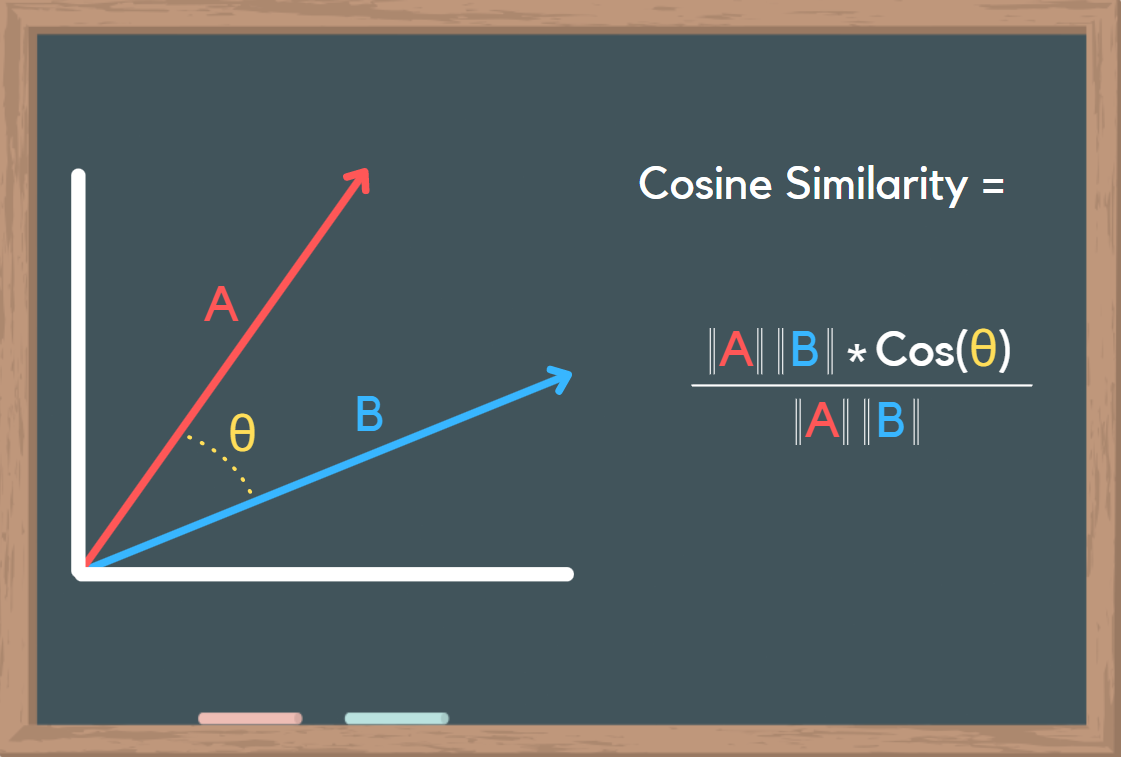



In [7]:
from langchain_ollama.embeddings import OllamaEmbeddings
embedding_model = OllamaEmbeddings(base_url=ollama_url,
                                    model="mxbai-embed-large:335m")        

**Run the following code in terminal**

```
$ ollama show mxbai-embed-large:335m

  Model

    - architecture        bert : the embedding model is based on a BERT-style transformer (encoder-style model commonly used for embeddings).
    - parameters          334M : the model has ~334 million learned weights. Larger parameter counts usually mean better quality but more compute/memory.    
    - context length      512  : the model can take up to 512 tokens of input text in one embedding call (tokens ≠ words; long text will be truncated or needs chunking).   
    - embedding length    1024 : each text input is mapped to a 1024-dimensional vector   
    - quantization        F16  : the model weights are stored/loaded in 16-bit floating point, often faster and lower memory than FP32 (and typically good for GPU). 

  Capabilities
    embedding    

  Parameters
    num_ctx    512    

```

In [32]:
sentence1 = "I deposited cash at the bank."
embedding1 = embedding_model.embed_query(sentence1)
len(embedding1)

1024

In [ ]:
sentence2 = "I sat by the river bank."
sentence3 = "It's a good dayto go to the bank"
embedding2 = embedding_model.embed_query(sentence2)
embedding3 = embedding_model.embed_query(sentence3)


In [30]:
from sklearn.metrics.pairwise import cosine_similarity
cos_sim1 = cosine_similarity([embedding1], [embedding2])[0, 0]
cos_sim2 = cosine_similarity([embedding1], [embedding3])[0, 0]
cos_sim3 = cosine_similarity([embedding2], [embedding3])[0, 0]

print(f"Cosine similarity between '{sentence1}' and '{sentence2}': {cos_sim1:.4f}")
print(f"Cosine similarity between '{sentence1}' and '{sentence3}': {cos_sim2:.4f}")
print(f"Cosine similarity between '{sentence2}' and '{sentence3}': {cos_sim3:.4f}")

Cosine similarity between 'I deposited cash at the bank.' and 'I sat by the river bank.': 0.5023
Cosine similarity between 'I deposited cash at the bank.' and 'It's a good dayto go to the bank': 0.7249
Cosine similarity between 'I sat by the river bank.' and 'It's a good dayto go to the bank': 0.4648


## Vectorstores
- We can always save and store the embedding so that next time, it can load faster
- Two commonly used vector stores available via ```langchain_community.vectorstores``` are **ChromaDB** and **FAISS**.
- Depending on Numpy version:
  - If np < 2 : Choose FAISS for faster in process vector search
  - If dont care about np version, Choose Chroma for easy persistence+metadata filtering

### ChromaDB
- ```Chroma.from_texts``` embed text only
- ```Chroma.from_documents``` embed document style

In [14]:
from langchain_community.vectorstores import Chroma

In [17]:
persist_directory = './docs/chroma/'

In [18]:
db_chroma = Chroma.from_documents(
    documents=splits,
    embedding=embedding_model,
    persist_directory=persist_directory
)

In [ ]:
db_chroma_reload = Chroma(
    persist_directory="docs/chroma/",
    embedding_function=embedding_model
)

### FAISS - Facebook AI Semantic Search
- ```FAISS.from_texts``` embed text only
- ```FAISS.from_documents``` embed document style, for vectordb, or chromadb


In [20]:
from langchain_community.vectorstores import FAISS

db_faiss = FAISS.from_documents(
    documents=splits,
    embedding=embedding_model
)

In [21]:
db_faiss.save_local("docs/faiss")

In [ ]:
db_faiss_reload = FAISS.load_local(
    "docs/faiss",
    oembedding,
    allow_dangerous_deserialization=True
)